<a href="https://colab.research.google.com/github/apeas1/PIDDeteccionVehiculos/blob/Pablo/Entrenamiento_epoch2030_batch10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pwd

'/content'

In [2]:
!git config --global user.name "pabrencau"
!git config --global user.email "pabrencau@alum.us.es"

In [3]:
!git clone https://token@github.com/apeas1/PIDDeteccionVehiculos.git

Cloning into 'PIDDeteccionVehiculos'...
remote: Enumerating objects: 5150, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 5150 (delta 2), reused 0 (delta 0), pack-reused 5141 (from 2)
Receiving objects: 100% (5150/5150), 493.66 MiB | 15.12 MiB/s, done.
Resolving deltas: 100% (25/25), done.
Updating files: 100% (7554/7554), done.


In [4]:
cd PIDDeteccionVehiculos

/content/PIDDeteccionVehiculos


In [5]:
ls

coches2.PNG                 Modelos/                     runs/
dataset.yaml                Obtencion_de_metricas.ipynb  VEHICLE-DETECTION-3/
Entrenamiento_YOLOv8.ipynb  README.md


In [6]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 59.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
!pip install roboflow
from roboflow import Roboflow

rf = Roboflow(api_key="oLgrOUnp0TT0CVeH8mYq")
project = rf.workspace("sardar-vallabhbhai-national-institute-if-technology").project("vehicle-detection-wagr7")
version = project.version(3)
dataset = version.download("yolov8-obb")


dataset = version.download("yolov8")
print("Dataset descargado en:", dataset.location)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 45.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


loading Roboflow workspace...
loading Roboflow project...
Dataset descargado en: /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3


In [8]:
%%writefile dataset.yaml
path: VEHICLE-DETECTION-3
train: train/images
val: valid/images
test: test/images  # Añadir también carpeta para los tests. Aunque no se mirará durante el entrenamiento

names:
  0: 3W
  1: Bus
  2: Coche
  3: Camioneta
  4: Motocicleta
  5: Camión Abierto
  6: Camion


Overwriting dataset.yaml


In [12]:
model = YOLO("/content/last.pt")  # modelo base ligero
model.conf = 0.35
model.iou = 0.45

model.train(
    data="dataset.yaml",    #El shuffle es automático
    epochs=30,
    imgsz=640,
    batch=10,
    augment=True,
    resume=False,
    model="yolov8n.yaml"
)

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretraine

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c8b393b1bb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

In [13]:
pwd

'/content/PIDDeteccionVehiculos'

   epoch      time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1   440.923         1.98925         1.05242         0.90071   
1      2   858.104         2.00370         1.06304         0.90423   
2      3  1281.900         2.00471         1.06495         0.90495   
3      4  1699.090         1.99104         1.06015         0.90237   
4      5  2119.050         1.99955         1.06525         0.90376   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.73139            0.71446           0.74684   
1               0.73368            0.70153           0.74440   
2               0.71775            0.71012           0.74563   
3               0.73475            0.71365           0.74294   
4               0.72214            0.72176           0.75447   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.38731       1.84077       0.97732       0.89908  0.000302   
1              0.38632       1.86334  

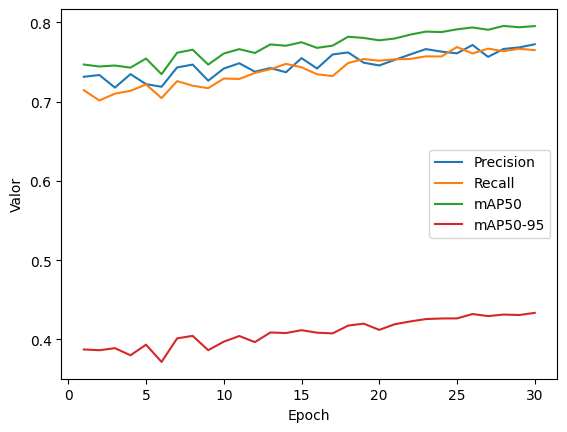

In [15]:
#MÉTRICAS VALIDACIÓN
#Mostrar las métricas mirando directamente el fichero donde se guardan

import pandas as pd
import matplotlib.pyplot as plt


# Cambia la ruta por tu experimento
df = pd.read_csv("runs/detect/train2/results.csv")
print(df.head())

#Mostrar las metricas
metrics = model.val()       #Por defecto está cogiendo las imagenes de validación. Equivalente a metrics = model.val(data="dataset.yaml", split="val")

print(metrics)

# ===============================
# MÉTRICAS ADICIONALES EN TEXTO
# ===============================
#print("\n===== MÉTRICAS DETALLADAS =====")

#print(f"📌 Imágenes evaluadas: {metrics.box.n_images}")
#print(f"📌 Objetos reales (GT): {metrics.box.n_targets}")

#print(f"📌 True Positives (TP): {metrics.box.tp.sum()}")
#print(f"📌 False Positives (FP): {metrics.box.fp.sum()}")
#print(f"📌 False Negatives (FN): {metrics.box.fn.sum()}")

#print("\n===== MÉTRICAS PRINCIPALES =====")
#print(f"Precision:    {metrics.box.p:.4f}")
#print(f"Recall:       {metrics.box.r:.4f}")
#print(f"F1 score:     {metrics.box.f1:.4f}")
#print(f"mAP50:        {metrics.box.map50:.4f}")
#print(f"mAP50-95:     {metrics.box.map:.4f}")

#Graficar métricas

import matplotlib.pyplot

plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
plt.xlabel('Epoch')
plt.ylabel('Valor')
plt.legend()
plt.show()


In [17]:
#MÉTRICAS TEST

metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test

print(metrics)

print("\n===== MÉTRICAS PRINCIPALES =====")
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision media:", metrics.box.mp)
print("Recall media:", metrics.box.mr)

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2254.1±574.0 MB/s, size: 88.5 KB)
val: Scanning /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels.cache... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 269.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.4s/it 22.1s
                   all        252      27305      0.755      0.787      0.801      0.441
                    3W        251       2972      0.805      0.773        0.8      0.331
                   Bus        125        364      0.817      0.959      0.942      0.637
                 Coche        251       8362      0.856      0.924      0.923      0.498
             Camioneta        182       1176       0.76      0.778      0.808      0.455
           Motocicleta        252      13488      0.683      0.446      0.529      0.177
     

In [19]:
import matplotlib.image as mpimg

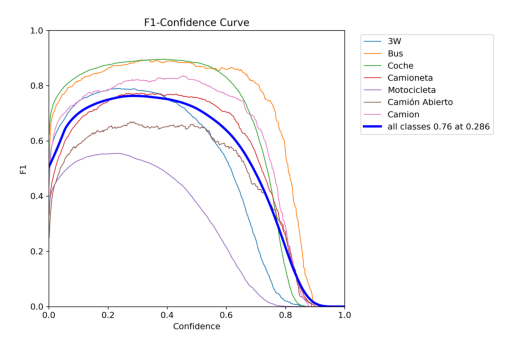

In [20]:
img1 = mpimg.imread('/content/PIDDeteccionVehiculos/runs/detect/val12/BoxF1_curve.png')
plt.imshow(img1)
plt.axis('off')
plt.show()

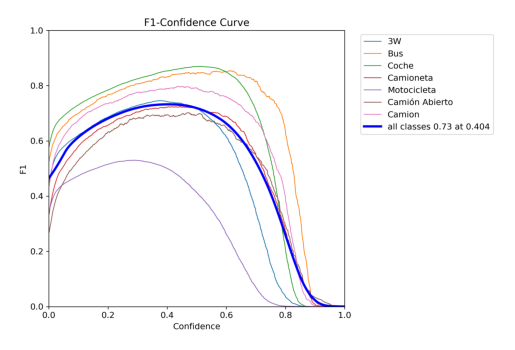

In [22]:
im1 = mpimg.imread('/content/PIDDeteccionVehiculos/runs/detect/train2/BoxF1_curve.png')
plt.imshow(im1)
plt.axis('off')
plt.show()

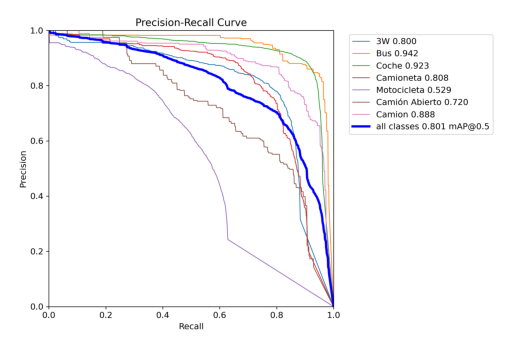

In [23]:
img2 = mpimg.imread('/content/PIDDeteccionVehiculos/runs/detect/val12/BoxPR_curve.png')
plt.imshow(img2)
plt.axis('off')
plt.show()

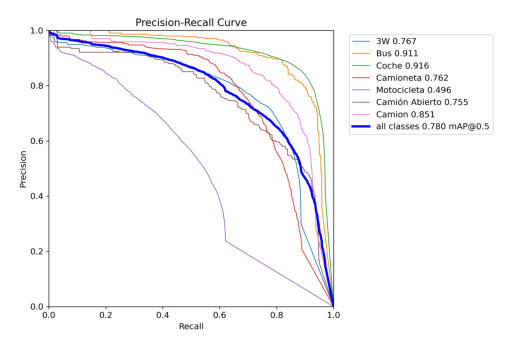

In [24]:
im2 = mpimg.imread('/content/PIDDeteccionVehiculos/runs/detect/train2/BoxPR_curve.png')
plt.imshow(im2)
plt.axis('off')
plt.show()

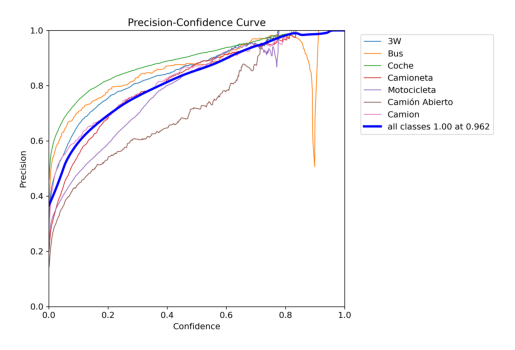

In [25]:
img3 = mpimg.imread('/content/PIDDeteccionVehiculos/runs/detect/val12/BoxP_curve.png')
plt.imshow(img3)
plt.axis('off')
plt.show()

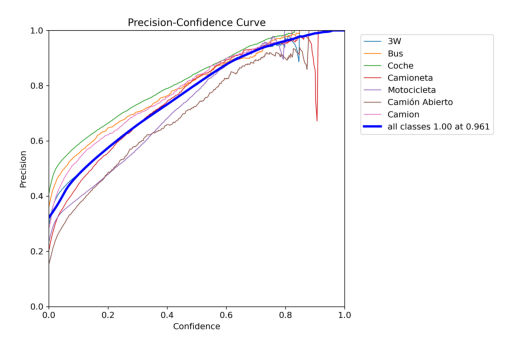

In [26]:
im3 = mpimg.imread('/content/PIDDeteccionVehiculos/runs/detect/train2/BoxP_curve.png')
plt.imshow(im3)
plt.axis('off')
plt.show()

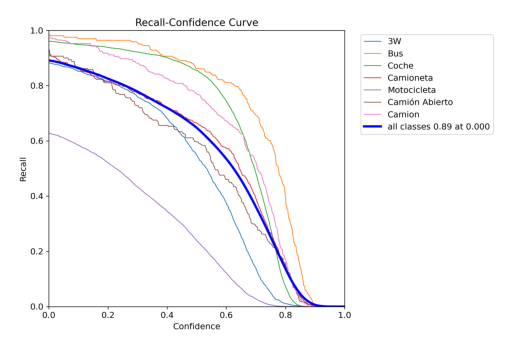

In [27]:
img4 = mpimg.imread('/content/PIDDeteccionVehiculos/runs/detect/val12/BoxR_curve.png')
plt.imshow(img4)
plt.axis('off')
plt.show()

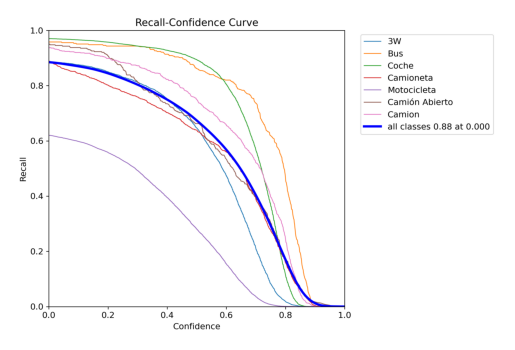

In [28]:
im4 = mpimg.imread('/content/PIDDeteccionVehiculos/runs/detect/train2/BoxR_curve.png')
plt.imshow(im4)
plt.axis('off')
plt.show()

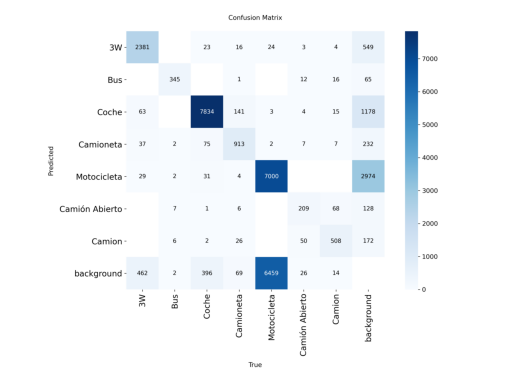

In [45]:
img_matriz_confusion = mpimg.imread('/content/PIDDeteccionVehiculos/runs/detect/val12/confusion_matrix.png')
plt.imshow(img_matriz_confusion)
plt.axis('off')
plt.show()

In [46]:
import numpy as np

Precisión: 0.7553654206970332
Recall: 0.7871915389930769
F1 score: 0.7650011951344958
mAP50-95: 0.4414099871940601
mAP50-95: 0.801350362825621
Matriz de confusión:


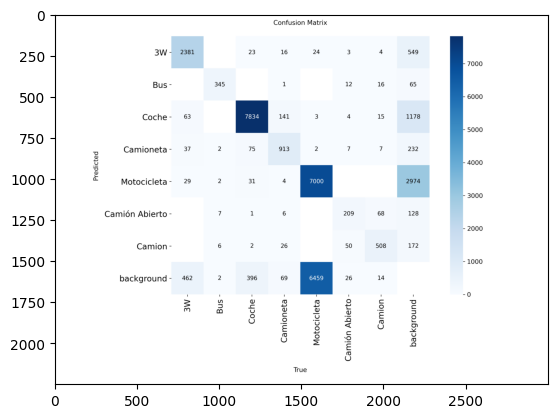

In [50]:
print("Precisión:", np.average(metrics.box.p))
print("Recall:", np.average(metrics.box.r))
print("F1 score:", np.average(metrics.box.f1))
print("mAP50-95:", np.average(metrics.box.map))
print("mAP50-95:", np.average(metrics.box.map50))
print("Matriz de confusión:")
plt.imshow(img_matriz_confusion)
plt.show()

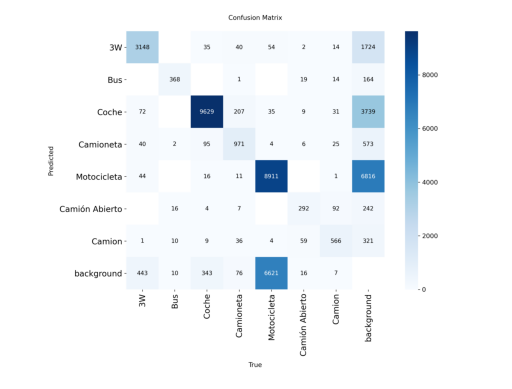

In [30]:
im5 = mpimg.imread('/content/PIDDeteccionVehiculos/runs/detect/train2/confusion_matrix.png')
plt.imshow(im5)
plt.axis('off')
plt.show()

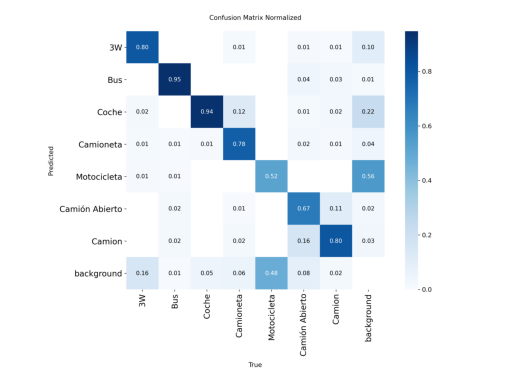

In [31]:
img6 = mpimg.imread('/content/PIDDeteccionVehiculos/runs/detect/val12/confusion_matrix_normalized.png')
plt.imshow(img6)
plt.axis('off')
plt.show()

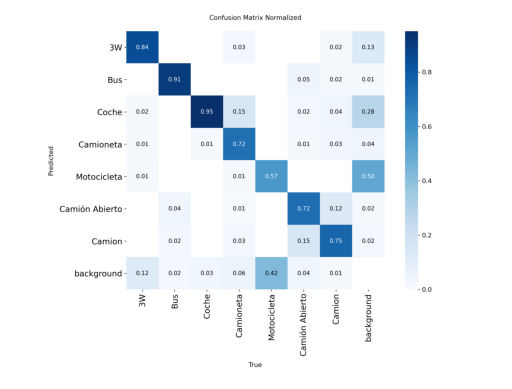

In [32]:
im6 = mpimg.imread('/content/PIDDeteccionVehiculos/runs/detect/train2/confusion_matrix_normalized.png')
plt.imshow(im6)
plt.axis('off')
plt.show()

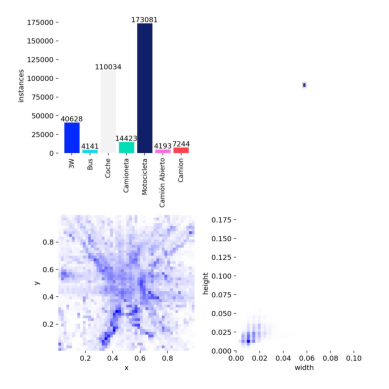

In [33]:
im7 = mpimg.imread('/content/PIDDeteccionVehiculos/runs/detect/train2/labels.jpg')
plt.imshow(im7)
plt.axis('off')
plt.show()

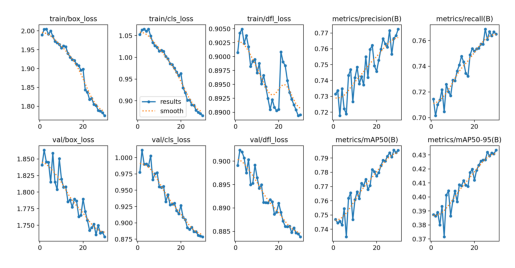

In [34]:
im8 = mpimg.imread('/content/PIDDeteccionVehiculos/runs/detect/train2/results.png')
plt.imshow(im8)
plt.axis('off')
plt.show()

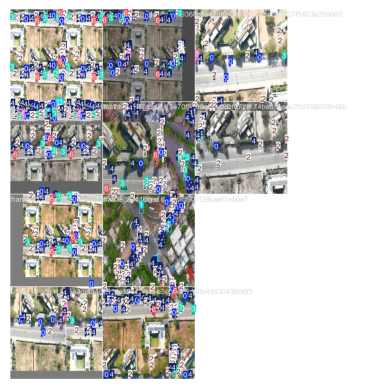

In [35]:
im9 = mpimg.imread('/content/PIDDeteccionVehiculos/runs/detect/train2/train_batch0.jpg')
plt.imshow(im9)
plt.axis('off')
plt.show()

In [36]:
results = model.predict('/content/coches.png', save=True)
#usar multi_label=False para asegurar que no está activado


image 1/1 /content/coches.png: 352x640 23 Coches, 1 Camioneta, 39.4ms
Speed: 1.9ms preprocess, 39.4ms inference, 1.4ms postprocess per image at shape (1, 3, 352, 640)
Results saved to /content/PIDDeteccionVehiculos/runs/detect/predict


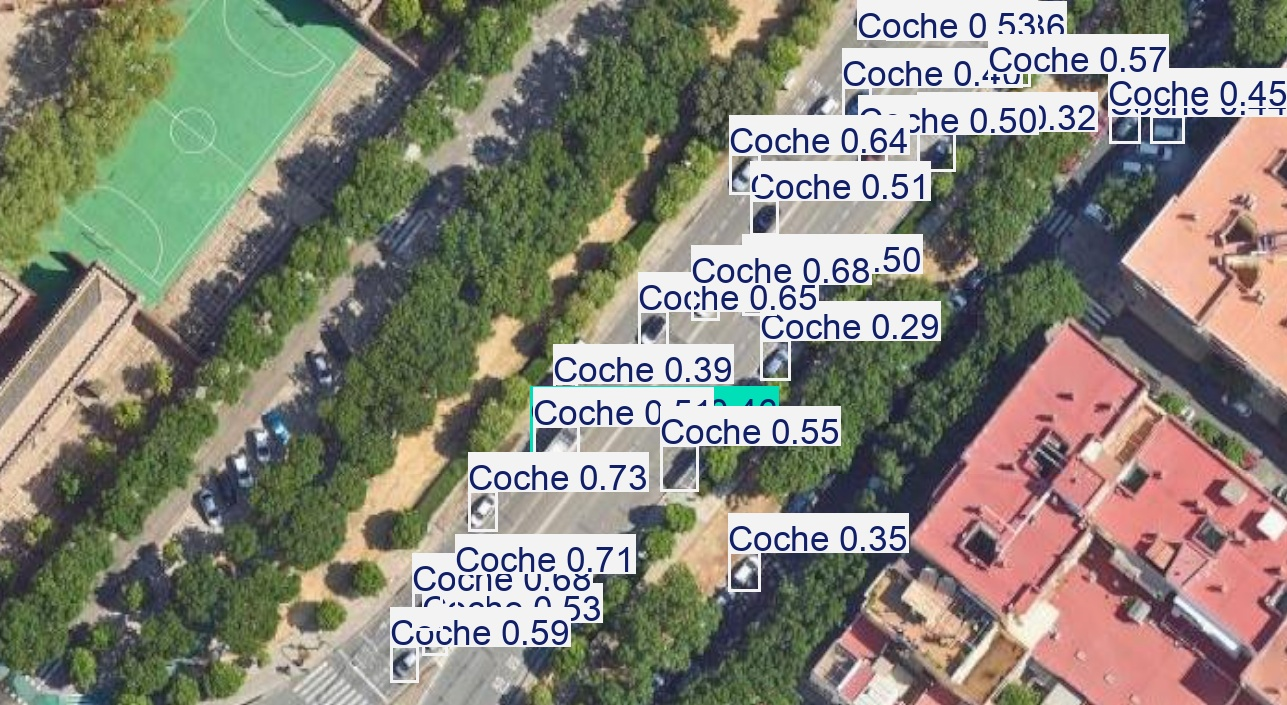

In [37]:
from google.colab.patches import cv2_imshow
import cv2

img = cv2.imread('runs/detect/predict/coches.jpg')
cv2_imshow(img)

In [40]:
results = model.predict('/content/coches2.png', iou=0.4, save=True)


image 1/1 /content/coches2.png: 320x640 34 Coches, 1 Camioneta, 1 Motocicleta, 1 Camion, 51.1ms
Speed: 16.0ms preprocess, 51.1ms inference, 8.1ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/PIDDeteccionVehiculos/runs/detect/predict


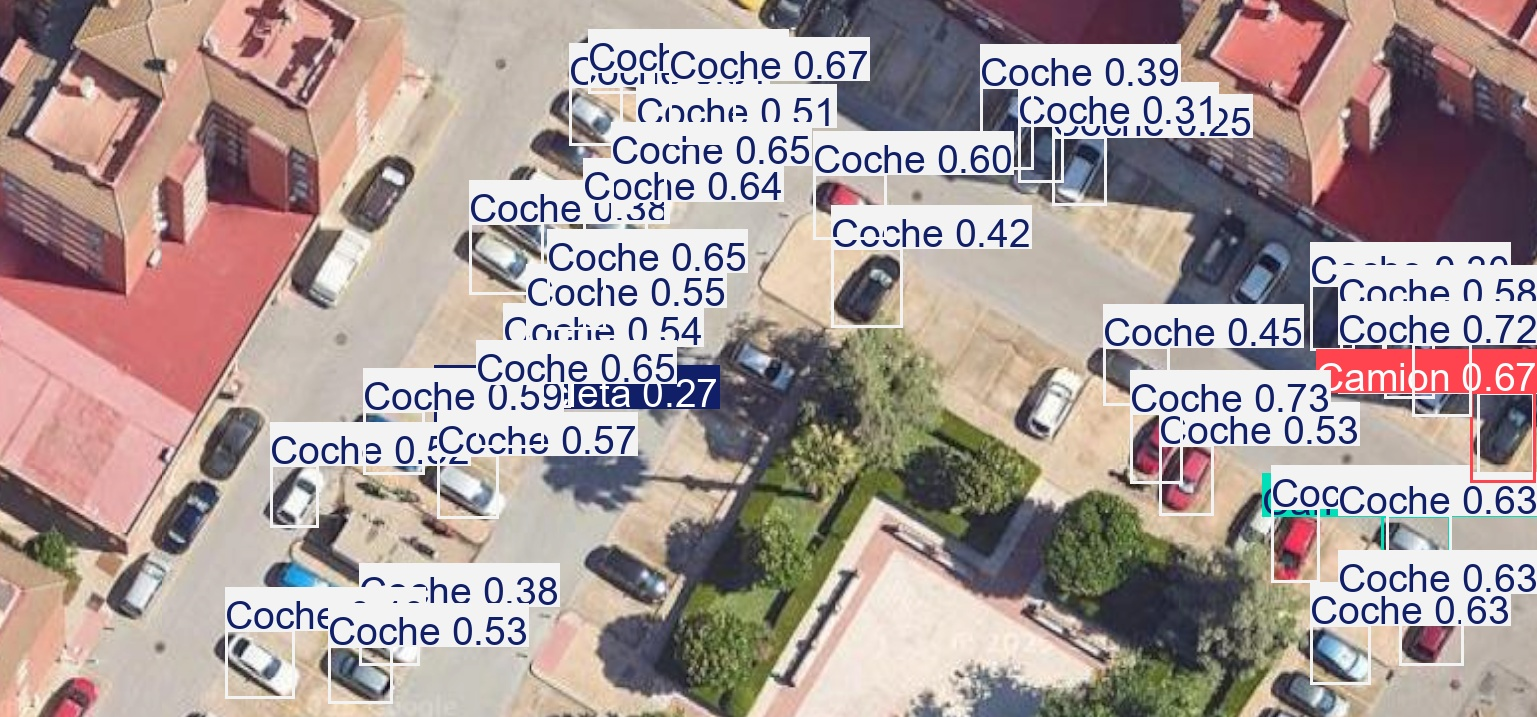

In [41]:
from google.colab.patches import cv2_imshow
import cv2

img = cv2.imread('runs/detect/predict/coches2.jpg')
cv2_imshow(img)

In [42]:
results = model.predict('/content/coches5.png', iou=0.4, save=True)


image 1/1 /content/coches5.png: 256x640 1 3W, 1 Bus, 66 Coches, 3 Motocicletas, 40.4ms
Speed: 1.8ms preprocess, 40.4ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 640)
Results saved to /content/PIDDeteccionVehiculos/runs/detect/predict


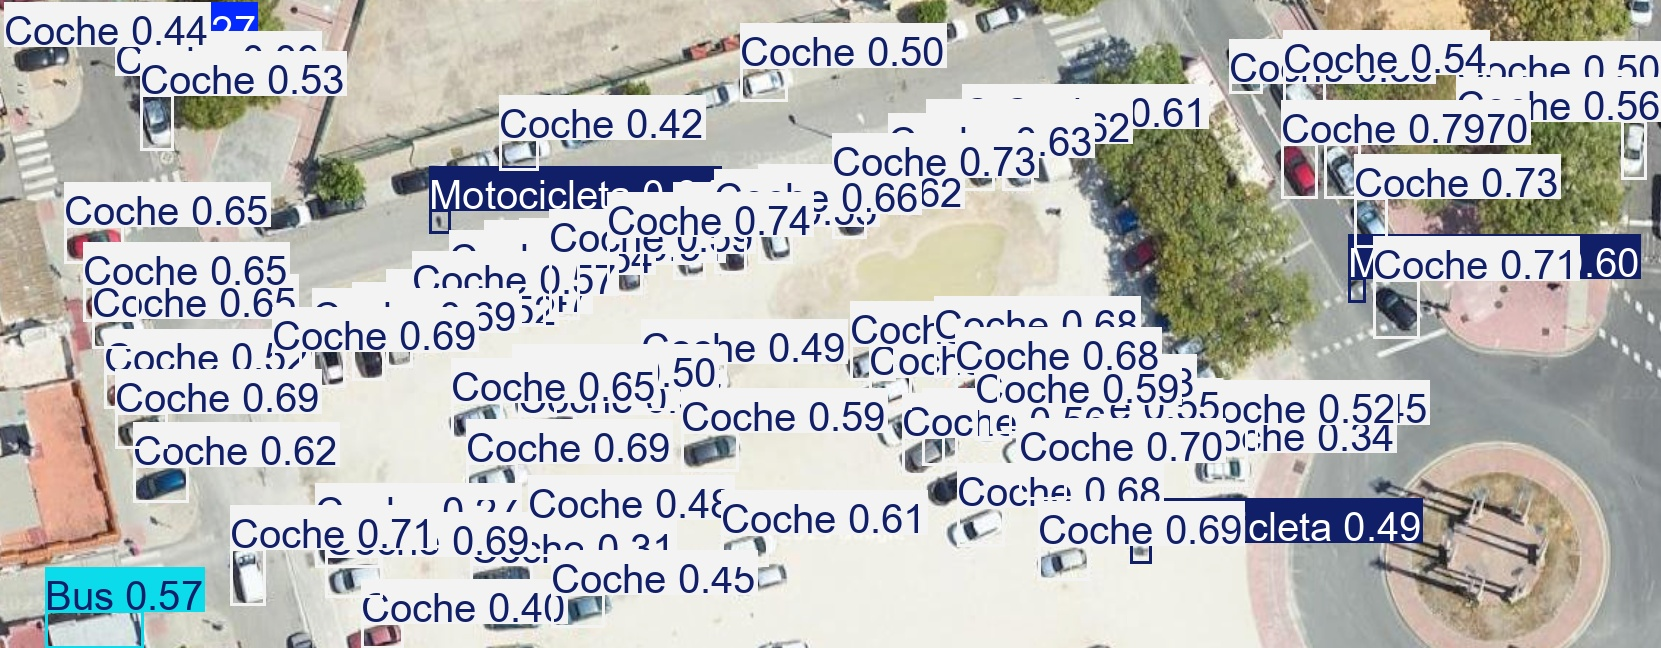

In [43]:
img = cv2.imread('runs/detect/predict/coches5.jpg')
cv2_imshow(img)

In [ ]:
!git pull

remote: Enumerating objects: 129, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 129 (delta 3), reused 1 (delta 1), pack-reused 119 (from 1)
Receiving objects: 100% (129/129), 97.26 MiB | 24.99 MiB/s, done.
Resolving deltas: 100% (12/12), completed with 1 local object.
From https://github.com/apeas1/PIDDeteccionVehiculos
   0ca070a..15914fa  main       -> origin/main
   89e7617..f8f8a58  Pablo      -> origin/Pablo
Updating 0ca070a..15914fa
error: Your local changes to the following files would be overwritten by merge:
	runs/detect/val/BoxF1_curve.png
	runs/detect/val/BoxPR_curve.png
	runs/detect/val/BoxP_curve.png
	runs/detect/val/BoxR_curve.png
	runs/detect/val/confusion_matrix.png
	runs/detect/val/confusion_matrix_normalized.png
	runs/detect/val/val_batch0_labels.jpg
	runs/detect/val/val_batch0_pred.jpg
	runs/detect/val/val_batch1_labels.jpg
	runs/detect/val/val_batch1_pred.jpg
	runs/detect/val/val_batch2_labels.jpg
	r

In [ ]:
!git add runs

In [ ]:
!git commit -m

error: switch `m' requires a value


In [ ]:
!git push origin Pablo

error: src refspec Pablo does not match any
error: failed to push some refs to 'https://github.com/apeas1/PIDDeteccionVehiculos.git'
